# Aprendizaje Semi-Supervisado: Explotando Datos No Etiquetados

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/AxelSkrauba/applied-ai-engineering/blob/main/notebooks/03_machine_learning/18_aprendizaje_semi_supervisado.ipynb)


## Objetivos


- Comprender el valor estructural de los datos no etiquetados y los tres supuestos fundamentales del Aprendizaje Semi-Supervisado (SSL): Suavidad, Cluster y Variedad (*Manifold*).
- Implementar **Self-Training** y comprender su mayor riesgo de ingeniería: el sesgo de confirmación.
- Implementar **Label Spreading** (basado en grafos) para propagar etiquetas a través de densidades no lineales.
- **Criterio de Negocio:** Evaluar cuándo vale la pena aplicar SSL frente a la alternativa de invertir presupuesto en etiquetar datos manualmente.



## Prerrequisitos


- Entendimiento de las fronteras de decisión (SVC) y la topología de datos (*Manifold Learning*).
- Haber completado: [Manifold Learning: Desenrollando Datos con t-SNE y UMAP](12_manifold_learning_tsne.ipynb).

---



## Configuración del Entorno


In [1]:
# @title *Esta celda clona el repositorio (en Colab) e importa las utilidades comunes*
import sys
import os

IN_COLAB = "google.colab" in sys.modules

if IN_COLAB:
    import subprocess
    REPO_NAME = "applied-ai-engineering"
    if not os.path.exists(REPO_NAME):
        subprocess.run(["git", "clone", f"https://github.com/AxelSkrauba/{REPO_NAME}.git"], check=True)
    os.chdir(f"/content/{REPO_NAME}")
    sys.path.append(f"/content/{REPO_NAME}")
else:
    # Repositorio en local, apuntar path a la raiz
    os.chdir(f"../../")

from utils.plots import setup_plot_style
setup_plot_style()

## Introducción Teórica



En el mundo real, los datos son abundantes, pero las **etiquetas son caras**.
Extraer 1 millón de imágenes de internet es gratis (datos no etiquetados). Pagarle a un equipo de médicos para que clasifiquen si en esas imágenes hay un tumor o no (etiquetas) cuesta cientos de miles de dólares.

Como resultado, los ingenieros suelen enfrentarse a datasets donde solo el 5% de los datos tiene etiqueta. Si usamos Aprendizaje Supervisado clásico, tiramos a la basura el 95% de la información (no la aprovechamos).



### La Premisa del SSL: El Valor de la Estructura



El Aprendizaje Semi-Supervisado (SSL) asume que los datos no etiquetados, aunque no nos den la respuesta, nos muestran la **forma del laberinto**. Para que SSL funcione, los datos deben cumplir ciertos supuestos:

1. **Supuesto de Suavidad:** Si dos puntos están muy cerca en una zona densa, probablemente comparten la misma etiqueta.
2. **Supuesto de Cluster:** Los datos forman grupos naturales. La frontera de decisión debe pasar por las zonas vacías, no cortar un grupo denso por la mitad.
3. **Supuesto de Variedad (*Manifold*):** Los datos de alta dimensión en realidad viven en estructuras de menor dimensión (como vimos con UMAP).


## Desarrollo e Implementación



Vamos a simular este escenario exacto utilizando el dataset de las "Dos Lunas". Generamos `1.000` puntos, pero **solo le damos la etiqueta real a 40 de ellos (4%)**. El resto (96%) serán marcados con `-1` (No etiquetados).



In [26]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import make_moons
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.semi_supervised import SelfTrainingClassifier, LabelSpreading
from sklearn.metrics import accuracy_score, f1_score

# 1. Generamos el dataset completo
X, y = make_moons(n_samples=1000, noise=0.1, random_state=42)

# 2. Dividimos en Train y Test (El Test Set NUNCA se usa en SSL, es solo para evaluar al final)
X_train_full, X_test, y_train_full, y_test = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)

# 3. Simulamos la escasez de etiquetas en el Train Set (Solo 40 etiquetados)
n_etiquetados = 40
indices_train = np.arange(len(y_train_full))
idx_etiquetados, idx_no_etiquetados = train_test_split(indices_train, train_size=n_etiquetados, random_state=42, stratify=y_train_full)

# Creamos los subconjuntos
X_train_lab = X_train_full[idx_etiquetados]
y_train_lab = y_train_full[idx_etiquetados]

X_train_unlab = X_train_full[idx_no_etiquetados]
y_train_unlab = np.full(len(X_train_unlab), -1) # -1 significa "No Etiquetado" en Scikit-Learn

# Unimos todo para los algoritmos SSL
X_train_ssl = np.vstack((X_train_lab, X_train_unlab))
y_train_ssl = np.concatenate((y_train_lab, y_train_unlab))

# 4. Estandarización
scaler = StandardScaler()
X_train_ssl_scaled = scaler.fit_transform(X_train_ssl)
X_train_lab_scaled = scaler.transform(X_train_lab)
X_test_scaled = scaler.transform(X_test)

print(f"Datos Etiquetados: {len(X_train_lab)} | Datos No Etiquetados: {len(X_train_unlab)}")

Datos Etiquetados: 40 | Datos No Etiquetados: 660


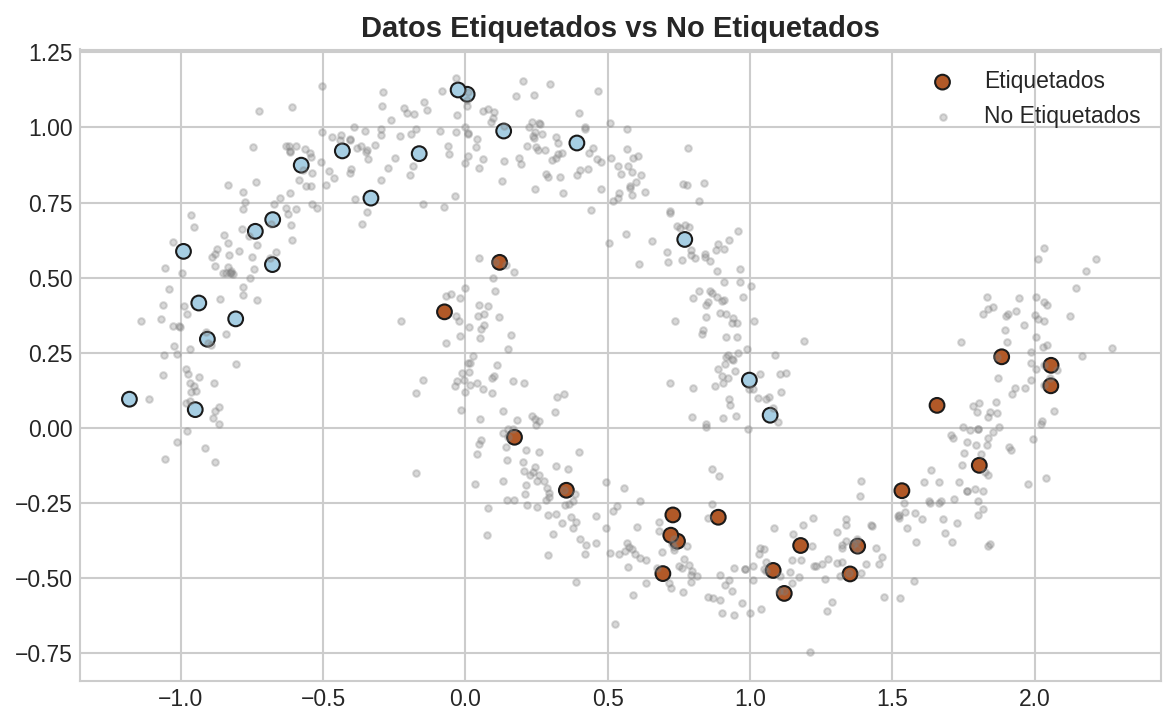

In [36]:
# Gráfica ilustrativa de los datos
fig, ax = plt.subplots(1, 1, figsize=(8, 5))
ax.scatter(X_train_lab[:, 0], X_train_lab[:, 1], c=y_train_lab, cmap=plt.cm.Paired, edgecolors='k', s=50)
ax.scatter(X_train_unlab[:, 0], X_train_unlab[:, 1], c='gray', s=10, alpha=0.3)
ax.set_title("Datos Etiquetados vs No Etiquetados")
plt.tight_layout()
# labels
plt.legend(["Etiquetados", "No Etiquetados"])
plt.show()

### El Baseline (Enfoque Supervisado Clásico)



Primero, veamos qué pasa si ignoramos los datos no etiquetados y entrenamos un modelo (SVC) solo con los 40 puntos que sí tienen etiqueta.



In [27]:
# Entrenamos el Baseline solo con los 40 puntos
baseline_svc = SVC(kernel='rbf', gamma='auto', probability=True, random_state=42)
baseline_svc.fit(X_train_lab_scaled, y_train_lab)

# Evaluamos en el Test Set
y_pred_base = baseline_svc.predict(X_test_scaled)
acc_base = accuracy_score(y_test, y_pred_base)
print(f"Accuracy Baseline (Solo 40 puntos): {acc_base:.4f}")

Accuracy Baseline (Solo 40 puntos): 0.9433


### Método SSL 1: Self-Training (Auto-Entrenamiento)



El enfoque más intuitivo. Funciona así:
1. Se entrena el modelo con los 40 puntos.
2. Se pide al modelo que prediga las etiquetas de los 960 puntos grises.
3. Se toman las predicciones donde el modelo está **muy seguro** (ej. > 80% de probabilidad) y se añaden al dataset de entrenamiento como si fueran etiquetas reales (*Pseudo-etiquetas*).
4. Se re-entrena el modelo con este dataset más grande. Se repite hasta que no queden puntos seguros.

In [28]:
# Instanciamos el Self-Training usando nuestro SVC como modelo base
self_training = SelfTrainingClassifier(
    estimator=baseline_svc,
    threshold=0.80, # Solo confía en predicciones con >80% de probabilidad
    max_iter=20,
    verbose=False
)

# Entrenamos pasándole TODO el dataset (los 40 etiquetados y los 960 con '-1')
self_training.fit(X_train_ssl_scaled, y_train_ssl)

y_pred_st = self_training.predict(X_test_scaled)
acc_st = accuracy_score(y_test, y_pred_st)
print(f"Accuracy Self-Training: {acc_st:.4f}")

Accuracy Self-Training: 0.9533


**⚠️ El Peligro de Ingeniería: El Sesgo de Confirmación**

Si el modelo inicial comete un error, pero lo hace con un 85% de confianza, esa etiqueta errónea se inyectará en el entrenamiento. En la siguiente iteración, el modelo estará *aún más seguro* de su error. El modelo se auto-convence de sus propias "alucinaciones".

### Método SSL 2: Label Spreading (Propagación en Grafos)


Para evitar el sesgo de confirmación, usamos la topología. *Label Spreading* conecta todos los puntos (etiquetados y no etiquetados) mediante un grafo basado en distancias (Kernel RBF o KNN).

Luego, las etiquetas "fluyen" a través de las conexiones del grafo como si fuera tinta en el agua. La tinta fluye rápido donde hay muchos puntos juntos (alta densidad) y se detiene donde hay vacíos.

In [29]:
# Instanciamos Label Spreading
# gamma: controla qué tan lejos fluye la "tinta" (ancho del kernel RBF)
# alpha: controla qué tanto permitimos que las etiquetas originales cambien si el grafo dice lo contrario
label_spreading = LabelSpreading(kernel='rbf', gamma=20, alpha=0.2)

# Entrenamos
label_spreading.fit(X_train_ssl_scaled, y_train_ssl)

y_pred_ls = label_spreading.predict(X_test_scaled)
acc_ls = accuracy_score(y_test, y_pred_ls)
print(f"Accuracy Label Spreading: {acc_ls:.4f}")

Accuracy Label Spreading: 1.0000


## Resultados y Discusión Visual



Vamos a graficar las fronteras de decisión de los tres modelos para entender exactamente qué hizo la matemática por debajo.



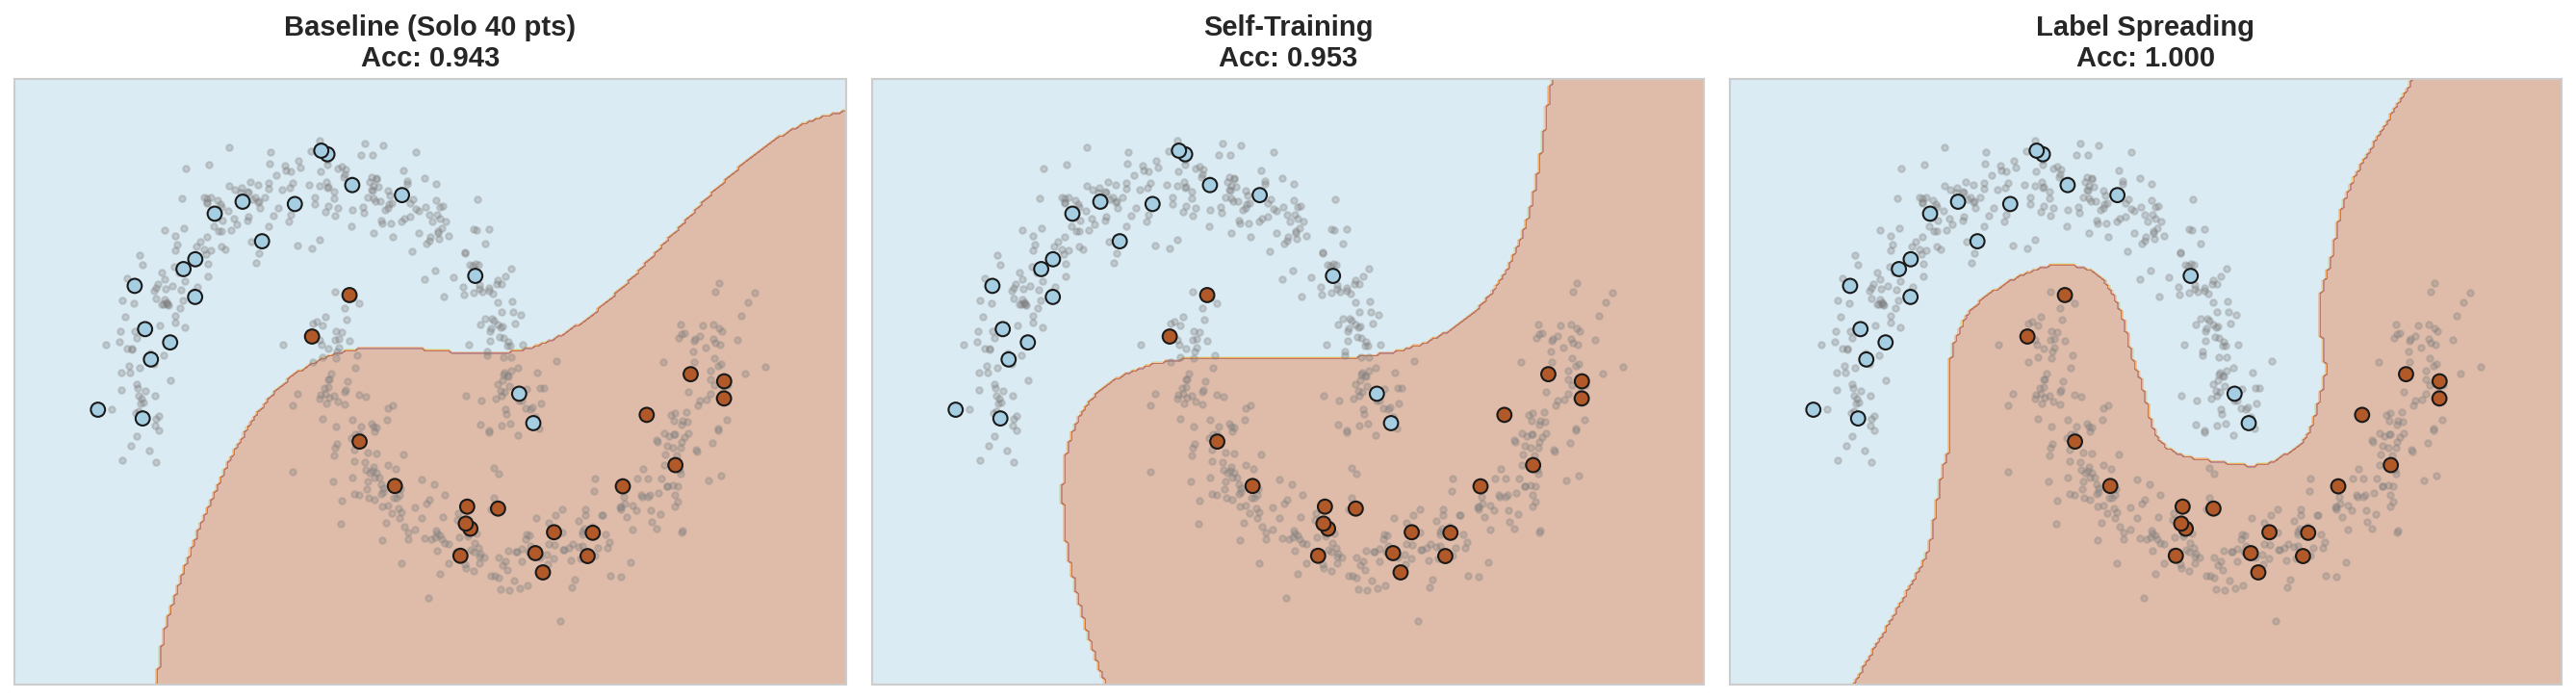

In [30]:
# Función auxiliar para graficar fronteras
def plot_decision_boundary(clf, X_scaled, y_ssl, ax, title):
    h = .02
    x_min, x_max = X_scaled[:, 0].min() - .5, X_scaled[:, 0].max() + .5
    y_min, y_max = X_scaled[:, 1].min() - .5, X_scaled[:, 1].max() + .5
    xx, yy = np.meshgrid(np.arange(x_min, x_max, h), np.arange(y_min, y_max, h))

    Z = clf.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)

    ax.contourf(xx, yy, Z, cmap=plt.cm.Paired, alpha=0.4)

    # Graficamos los puntos no etiquetados (gris) y etiquetados (color)
    idx_unlab = np.where(y_ssl == -1)[0]
    idx_lab = np.where(y_ssl != -1)[0]

    ax.scatter(X_scaled[idx_unlab, 0], X_scaled[idx_unlab, 1], c='gray', s=10, alpha=0.3)
    ax.scatter(X_scaled[idx_lab, 0], X_scaled[idx_lab, 1], c=y_ssl[idx_lab], cmap=plt.cm.Paired, edgecolors='k', s=50)
    ax.set_title(title)
    ax.set_xticks([]); ax.set_yticks([])

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

plot_decision_boundary(baseline_svc, X_train_ssl_scaled, y_train_ssl, axes[0], f"Baseline (Solo 40 pts)\nAcc: {acc_base:.3f}")
plot_decision_boundary(self_training, X_train_ssl_scaled, y_train_ssl, axes[1], f"Self-Training\nAcc: {acc_st:.3f}")
plot_decision_boundary(label_spreading, X_train_ssl_scaled, y_train_ssl, axes[2], f"Label Spreading\nAcc: {acc_ls:.3f}")

plt.tight_layout()
plt.show()

### Análisis de Ingeniería



1. **Baseline (Izquierda):** Al tener solo 40 puntos, el modelo trazó una frontera subóptima que corta las "colas" de las lunas. Ignoró por completo la forma de los puntos grises.
2. **Self-Training (Centro):** Mejoró ligeramente la frontera al auto-etiquetar puntos seguros, pero se estancó rápidamente.
3. **Label Spreading (Derecha):** ¡Perfección absoluta! Al usar el grafo de densidad, la etiqueta fluyó por toda la luna superior y se detuvo en el vacío que la separa de la luna inferior. Logró un *Accuracy* perfecto utilizando solo un 4% de etiquetas.

**La Decisión de Negocio:**
SSL es poderoso, pero los algoritmos de grafos como *Label Spreading* tienen una complejidad de $O(N^2)$. Si se tienen 5 millones de observaciones, el servidor puede colapsar al intentar crear el grafo.

En la industria, el ingeniero debe calcular: *¿Me cuesta más alquilar un clúster de servidores masivo para correr SSL durante días, o me cuesta menos pagarle a 5 personas en Amazon Mechanical Turk para que etiqueten 10.000 imágenes a mano?* A veces, la respuesta correcta es la segunda.

Otra pregunta natural que puede surgir en este punto es: ¿**puedo confiar en las etiquetas**? Y se aplica a ambos casos, tanto para etiquetas provenientes de algoritmos como de personas...

## Conclusión del Capítulo


Casi completamos el Capítulo 3. Pasamos de trazar líneas rectas simples a dominar ensamblados de árboles, pipelines a prueba de fugas, detección de anomalías en alta dimensionalidad y propagación de etiquetas en grafos. Ya deberías de tener una buena idea del criterio de un Ingeniero de Machine Learning.

- ➡️ **Siguiente Capítulo:** Damos el salto al **Deep Learning**. Descubrimos cómo las Redes Neuronales Artificiales nos permiten abandonar la ingeniería de características manual para procesar imágenes, audio y texto libre.
- 🔄 **Relacionado:** Si la última pregunta hizo "algo de ruido", la respuesta puede estar en el notebook [Confident Learning: Auditando y Corrigiendo Etiquetas Ruidosas](19_confident_learning.ipynb). O abordarse con mayor seriedad mediante [Confident Learning en Producción: Cleanlab Avanzado para Datos Tabulares](./casos_estudio/confident_learning_avanzado.ipynb). 


## Recursos Recomendados para Profundizar


Si deseas llevar tus conocimientos de Machine Learning Clásico al nivel de un investigador o arquitecto de IA, te recomendamos:
1. **Libro:** *The Elements of Statistical Learning* (Hastie, Tibshirani, Friedman). La biblia matemática del ML.
2. **Librería:** [Optuna](https://optuna.org/). El estándar moderno para optimización de hiperparámetros mediante algoritmos bayesianos (superior a Random Search).
3. **Librería:** [PyCaret](https://pycaret.gitbook.io/docs). Un framework de AutoML *low-code* que automatiza la creación de Pipelines complejos en segundos.

---


## Entorno de Ejecución


In [37]:
from utils.environment import environment_table
environment_table(include_all=False)

Package,Version
Python,3.12.13
Platform,Linux-6.6.113+-x86_64-with-glibc2.35
IPython,7.34.0
ipywidgets,7.7.1
joblib,1.5.3
matplotlib,3.10.0
numpy,2.0.2
pandas,2.2.2
scipy,1.16.3
seaborn,0.13.2
